<a href="https://colab.research.google.com/github/gitcnk/Time_Series_Forecasting/blob/main/jena_climate_rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN Time Series Forecasting on Jena Climate Dataset

This notebook builds a SimpleRNN model to predict temperature using all 14 variables from the Jena Climate dataset.

**README:** Please use a GPU runtime for fast execution.  It takes about 100 seconds per epoch with batch size of 256.

## 1. Import Libraries

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

## 2. Load and Explore the Dataset

In [11]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

import os
fname = os.path.join("jena_climate_2009_2016.csv")


--2026-04-19 20:05:20--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.223.128, 52.217.46.70, 52.216.89.5, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.223.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip.1’

jena_climate_2009_2 100%[===================>]  12.94M  22.8MB/s    in 0.6s    

2026-04-19 20:05:21 (22.8 MB/s) - ‘jena_climate_2009_2016.csv.zip.1’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
replace jena_climate_2009_2016.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace __MACOSX/._jena_climate_2009_2016.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [12]:
# Load the Jena Climate dataset
df = pd.read_csv(fname)

# Display dataset info
df.shape

df.head()


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## Choose the Predictors for the model

In [20]:
predictor_indices = [1, 2, 4, 5]  # Pressure, Temperature(C), Dew, Rel.Humidity
data = df.iloc[:, predictor_indices].values

data[0:4, :]

array([[996.52,  -8.02,  -8.9 ,  93.3 ],
       [996.57,  -8.41,  -9.28,  93.4 ],
       [996.53,  -8.51,  -9.31,  93.9 ],
       [996.51,  -8.31,  -9.07,  94.2 ]])

In [21]:
# Normalize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

## 4. Create Time Series Datasets

Use `keras.utils.timeseries_dataset_from_array` to create batched time series datasets.

In [22]:
# Hyperparameters
seq_length = 120  # Use 100 timesteps to predict the next value
batch_size = 256
train_split = int(len(data_scaled) * 0.8)

# Split data before creating datasets
train_data = data_scaled[:train_split]
test_data = data_scaled[train_split:]

In [23]:
# Create training dataset
train_dataset = keras.utils.timeseries_dataset_from_array(
    data=train_data,
    targets=train_data[:, 1],  # Predict temperature (second column)
    sequence_length=seq_length,
    sampling_rate=1,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

In [24]:
# Create validation dataset (from last 20% of training data)
val_split = int(len(train_data) * 0.8)
val_data = train_data[val_split:]
val_targets = train_data[val_split:, 1]

val_dataset = keras.utils.timeseries_dataset_from_array(
    data=train_data,
    targets=train_data[:, 1],
    sequence_length=seq_length,
    sampling_rate=1,
    batch_size=batch_size,
    shuffle=False
)

In [25]:
# Create test dataset
test_dataset = keras.utils.timeseries_dataset_from_array(
    data=test_data,
    targets=test_data[:, 1],  # Predict temperature
    sequence_length=seq_length,
    sampling_rate=1,
    batch_size=batch_size,
    shuffle=False
)

train_data.shape
test_data.shape
batch_size

256

## 5. Build the RNN Model

In [29]:
# Number of predictors
p = 4

# Build RNN model
model = keras.Sequential([
    layers.SimpleRNN(128, activation='relu', input_shape=(seq_length, p), return_sequences=True),
    layers.Dropout(0.2),
    layers.SimpleRNN(64, activation='relu', return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Simple NN

model = keras.Sequential([
    # Input: (batch_size, seq_length=100, num_predictors=3)
    layers.Dense(256,
                 activation='relu',
                 input_shape=(seq_length, num_predictors)),
    layers.Dropout(0.3),

    # Second Dense layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Third Dense layer
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    # Fourth Dense layer
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    # Flatten: (batch_size, seq_length, 32) -> (batch_size, seq_length*32)
    layers.Flatten(),

    # Fifth Dense layer
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.1),

    # Output layer
    layers.Dense(1)
])


In [30]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


model.summary()

Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 120, 128)       │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,489 (123.00 KB)

 Trainable params: 31,489 (123.00 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

In [31]:
# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    verbose=1
)

Epoch 1/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 113s 81ms/step - loss: 0.2040 - mae: 0.3528 - val_loss: 0.1966 - val_mae: 0.3463
Epoch 2/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 102s 77ms/step - loss: 0.1856 - mae: 0.3357 - val_loss: 0.2152 - val_mae: 0.3628
Epoch 3/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 102s 77ms/step - loss: 0.1809 - mae: 0.3312 - val_loss: 0.2049 - val_mae: 0.3550
Epoch 4/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 102s 77ms/step - loss: 0.1796 - mae: 0.3293 - val_loss: 0.2006 - val_mae: 0.3515
Epoch 5/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 104s 79ms/step - loss: 0.1780 - mae: 0.3284 - val_loss: 0.1894 - val_mae: 0.3383
Epoch 6/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 103s 78ms/step - loss: 0.1806 - mae: 0.3309 - val_loss: 0.2017 - val_mae: 0.3504
Epoch 7/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 105s 80ms/step - loss: 0.1778 - mae: 0.3283 - val_loss: 0.2019 - val_mae: 0.3500
Epoch 8/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 104s 79ms/step - loss: 0.1844 - mae: 0.3353 - val_loss: 0.2057 - val_mae: 0.3554
Epoch 9/10
1314/

## 7. Evaluate on Test Set

In [ ]:
# Evaluate on test set
test_loss, test_mae = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

329/329 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 0.2177 - mae: 0.3585
Test Loss: 0.2177
Test MAE: 0.3585


## 8. Make Predictions and Calculate Metrics

In [ ]:
# Make predictions on test set
y_pred_test = model.predict(test_dataset, verbose=0)

# Get actual test targets
y_test = np.concatenate([y for x, y in test_dataset], axis=0)

In [ ]:
# Inverse transform to original scale (only for temperature - column 0)
# Create dummy arrays with the right shape for inverse transform
y_test_dummy = np.zeros((len(y_test), 14))
y_test_dummy[:, 1] = y_test.flatten()
y_test_original = scaler.inverse_transform(y_test_dummy)[:, 1]

y_pred_test_dummy = np.zeros((len(y_pred_test), 14))
y_pred_test_dummy[:, 1] = y_pred_test.flatten()
y_pred_test_original = scaler.inverse_transform(y_pred_test_dummy)[:, 1]

In [ ]:
# Calculate RMSE
test_rmse = np.sqrt(np.mean((y_pred_test_original - y_test_original) ** 2))
print(f"Test RMSE: {test_rmse:.4f}")

Test RMSE: 3.9305


## 9. Visualize Results

In [ ]:
# Plotting
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot training history
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss During Training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot predictions vs actual
test_indices = range(len(y_pred_test_original))
axes[1].plot(test_indices, y_test_original, label='Actual', linewidth=2)
axes[1].plot(test_indices, y_pred_test_original, label='Predicted', alpha=0.8)
axes[1].set_title('Temperature Predictions vs Actual (Test Set)')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

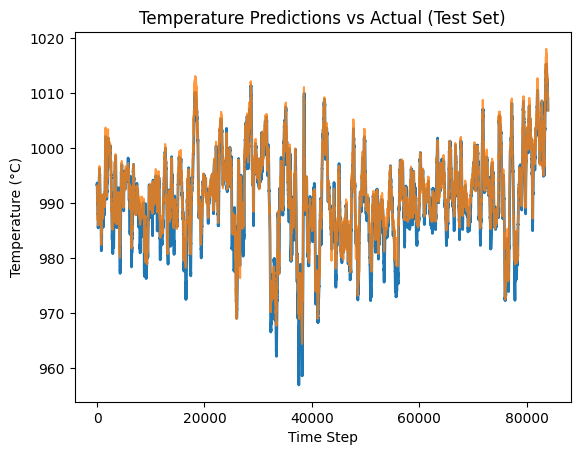

In [ ]:
test_indices = range(len(y_pred_test_original))
plt.plot(test_indices, y_test_original, label='Actual', linewidth=2)
plt.plot(test_indices, y_pred_test_original, label='Predicted', alpha=0.8)
plt.title('Temperature Predictions vs Actual (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.show()